In [ ]:
    from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.neural_network import MLPRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import KFold, GridSearchCV
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score, make_scorer
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression
from collections import Counter

In [ ]:
# train_data = pd.read_csv('/content/drive/MyDrive/DS/cleaned_data_train.csv')
# test_data = pd.read_csv('/content/drive/MyDrive/DS/cleaned_data_test.csv')
train_data = pd.read_csv('/content/drive/MyDrive/Colab Notebooks/ds/cleaned_data_train.csv')
test_data = pd.read_csv('/content/drive/MyDrive/Colab Notebooks/ds/cleaned_data_test.csv')

In [ ]:
train_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6028 entries, 0 to 6027
Data columns (total 14 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   temp_c               6028 non-null   float64
 1   precip_mm            6028 non-null   float64
 2   humidity             6028 non-null   int64  
 3   pressure_mb          6028 non-null   float64
 4   wind_kph             6028 non-null   float64
 5   cloud                6028 non-null   int64  
 6   dewpoint_c           6028 non-null   float64
 7   feelslike_c          6028 non-null   float64
 8   vis_km               6028 non-null   float64
 9   gust_kph             6028 non-null   float64
 10  condition            6028 non-null   object 
 11  dewpoint_depression  6028 non-null   float64
 12  hour                 6028 non-null   int64  
 13  condition_encoded    6028 non-null   int64  
dtypes: float64(9), int64(4), object(1)
memory usage: 659.4+ KB


In [ ]:
features = ['cloud', 'pressure_mb', 'dewpoint_depression', 'humidity']
target = 'feelslike_c'
train_df = train_data.dropna(subset=features + [target])
test_df = test_data.dropna(subset=features + [target])
X_train = train_df[features]
y_train = train_df[target]
X_test = test_df[features]
y_test = test_df[target]

In [ ]:
def show_result(model):
    y_test_pred = model.predict(X_test_scaled)
    all_y_test = np.array(y_test)
    all_y_pred = np.array(y_test_pred)

    plt.figure(figsize=(8, 6))
    plt.scatter(y_test_pred, all_y_test, alpha=0.7, color='b', label='Dự đoán')
    plt.plot([all_y_test.min(), all_y_test.max()], [all_y_test.min(), all_y_test.max()], 'r--', lw=2, label='Dự đoán hoàn hảo (y = x)')
    plt.xlabel('Giá trị thực tế (°C)')
    plt.ylabel('Giá trị dự đoán (°C)')
    plt.title(f'So sánh giá trị thực và dự đoán\n')
    plt.legend()
    plt.grid(True)
    plt.tight_layout()
    plt.show()

## Chọn mô hình phân lớp với Nested Cross-Validation

Hàm `lua_chon_mo_hinh_phan_lop` được sử dụng để lựa chọn mô hình phân lớp tối ưu bằng phương pháp **Nested Cross-Validation** kết hợp với **GridSearchCV**. Mục tiêu là đánh giá hiệu suất thực sự của mô hình sau khi tìm được siêu tham số tối ưu, từ đó tránh được tình trạng overfitting khi chọn siêu tham số.

### Outer Loop (outer_cv):
Chia dữ liệu thành 5 phần (5-fold). Mỗi vòng lặp sẽ giữ lại 1 phần làm tập kiểm tra bên ngoài (outer test), 4 phần còn lại dùng để huấn luyện và chọn siêu tham số.
Mục tiêu: Đánh giá chính xác hiệu suất mô hình cuối cùng.

### Inner Loop (inner_cv):
Với 4 phần của outer training set, tiếp tục chia thành 3 phần để huấn luyện và validate. Dùng để tìm tổ hợp siêu tham số tốt nhất.

### GridSearchCV:
GridSearchCV là công cụ tìm kiếm tổ hợp siêu tham số tốt nhất thông qua việc thử toàn bộ các cấu hình trong param_grid. Với mỗi cấu hình, mô hình sẽ được huấn luyện nhiều lần theo số fold của inner_cv, sau đó chọn ra mô hình có độ chính xác (accuracy) cao nhất.

1. estimator: Mô hình cơ sở (VD: RandomForestRegressor, XGBRegressor)

2. param_grid: Tập hợp các siêu tham số cần thử

3. scoring='accuracy': Tiêu chí đánh giá mô hình là độ chính xác

4. n_jobs=-1: Tận dụng tối đa CPU để tăng tốc tính toán

### Hàm Loss – Mean Squared Error (MSE)

**Mục đích**: Đo lường sai số bình phương trung bình giữa giá trị thực và dự đoán.

**Công thức**:

$$ {{MSE} = \frac{1}{n} \sum_{i=1}^{n} (y_i - \hat{y}_i)^2} $$

In [ ]:
def lua_chon_mo_hinh(X, y, param_grid, base_model):
    # Outer loop: đánh giá tổng thể mô hình
    outer_cv = KFold(n_splits=5, shuffle=True, random_state=42)

    # Inner loop: chọn siêu tham số
    inner_cv = KFold(n_splits=3, shuffle=True, random_state=1)

    mse_scores = []
    r2_scores = []
    all_best_params = []

    fold = 1
    for train_idx, val_idx in outer_cv.split(X):
        print(f'\n----- Fold {fold} -----')

        X_train, X_val = X.iloc[train_idx], X.iloc[val_idx]
        y_train, y_val = y.iloc[train_idx], y.iloc[val_idx]

        # Tìm mô hình tốt nhất bằng GridSearchCV trong inner loop
        grid_search = GridSearchCV(
            estimator=base_model,
            param_grid=param_grid,
            cv=inner_cv,
            scoring=make_scorer(mean_squared_error, greater_is_better=False),
            n_jobs=-1,
            verbose=0
        )
        grid_search.fit(X_train, y_train)
        best_model = grid_search.best_estimator_

        print("Best parameters:", grid_search.best_params_)
        all_best_params.append(grid_search.best_params_)

        y_pred = best_model.predict(X_test)

        mse = mean_squared_error(y_test, y_pred)
        r2 = r2_score(y_test, y_pred)

        print(f'MSE: {mse:.4f}')
        print(f'R² : {r2:.4f}')

        # Lưu kết quả
        mse_scores.append(mse)
        r2_scores.append(r2)

        fold += 1

    print('\n====== Kết quả trung bình sau 5 fold ======')
    mean_mse = np.mean(mse_scores)
    mean_r2 = np.mean(r2_scores)
    print(f'MSE trung bình: {mean_mse:.4f}')
    print(f'R² trung bình : {mean_r2:.4f}')

    most_common_params = Counter(tuple(sorted(p.items())) for p in all_best_params).most_common(1)[0][0]

    best_params = dict(most_common_params)
    return best_params

## Huấn luyện và đánh giá mô hình dự đoán Random Forest

Huấn luyện mô hình Random Forest + GridSearch. Sử dụng `RandomForestRegressor` làm mô hình cơ sở, kết hợp với `GridSearchCV` để tìm ra tổ hợp siêu tham số tốt nhất qua hàm `lua_chon_mo_hinh_phan_lop`


In [ ]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

base_model = RandomForestRegressor(random_state=42)
param_grid = {
    'n_estimators': [50, 100, 200],
    'max_depth': [None, 5, 10]
}
best_params = lua_chon_mo_hinh(X_train, y_train, param_grid, base_model)


----- Fold 1 -----
Best parameters: {'max_depth': 10, 'n_estimators': 200}
MSE: 3.2889
R² : 0.8226

----- Fold 2 -----
Best parameters: {'max_depth': 10, 'n_estimators': 200}
MSE: 3.3989
R² : 0.8167

----- Fold 3 -----
Best parameters: {'max_depth': 10, 'n_estimators': 200}
MSE: 3.2840
R² : 0.8229

----- Fold 4 -----
Best parameters: {'max_depth': 10, 'n_estimators': 200}
MSE: 3.3050
R² : 0.8217

----- Fold 5 -----
Best parameters: {'max_depth': 10, 'n_estimators': 200}
MSE: 3.3607
R² : 0.8187

====== Kết quả trung bình sau 5 fold ======
MSE trung bình: 3.3275
R² trung bình : 0.8205


In [ ]:
print(f'siêu tham số tốt nhất: {best_params}')

siêu tham số tốt nhất: {'max_depth': 10, 'n_estimators': 200}


## các siêu tham số trong mô hình Random Forest Regressor

1. n_estimators = 100: Là số lượng cây (decision trees) trong rừng ngẫu nhiên.
2. max_depth = 10: giới hạn độ sâu tối đa của mỗi cây.



=== Đánh giá trên Test Set ===
Test MSE: 3.2660
Test R2 : 0.8238


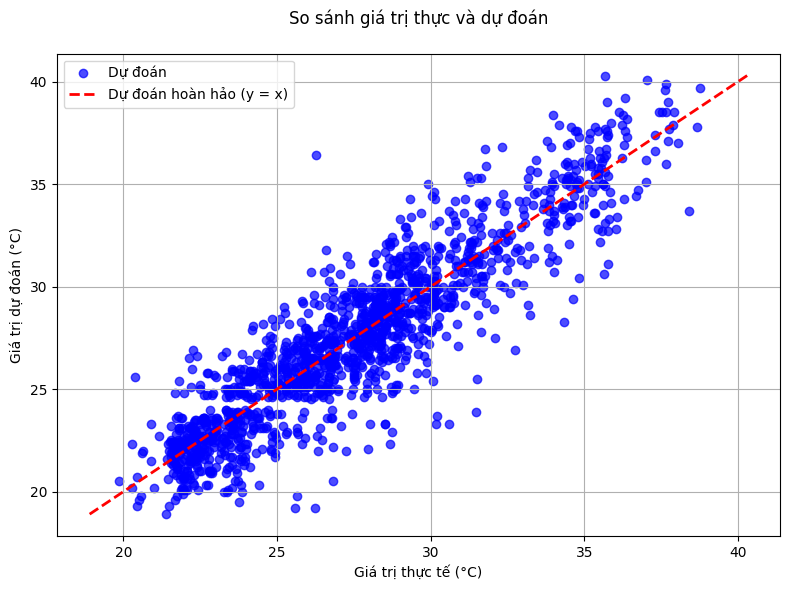

In [ ]:
rf_model = RandomForestRegressor(**best_params, random_state=42)
rf_model.fit(X_train_scaled, y_train)

y_test_pred = rf_model.predict(X_test_scaled)

print("\n=== Đánh giá trên Test Set ===")
print(f"Test MSE: {mean_squared_error(y_test, y_test_pred):.4f}")
print(f"Test R2 : {r2_score(y_test, y_test_pred):.4f}")

show_result(rf_model)

## Tìm siêu tham số, huấn luyện, và đánh giá mô hình XGBRegression

Huấn luyện mô hình MLPClassifier + GridSearch. Sử dụng `XGBRegression` làm mô hình cơ sở, kết hợp với `GridSearchCV` để tìm ra tổ hợp siêu tham số tốt nhất qua hàm `lua_chon_mo_hinh_phan_lop`

In [ ]:
from xgboost import XGBRegressor
from sklearn.metrics import mean_squared_error, r2_score

base_model = XGBRegressor(random_state=42)

param_grid = {
    'n_estimators': [100, 200],
    'max_depth': [5, 10],
    'learning_rate': [0.05, 0.1],
    'subsample': [0.8, 1.0]
}

best_params = lua_chon_mo_hinh(X_train, y_train, param_grid, base_model)



----- Fold 1 -----
Best parameters: {'learning_rate': 0.05, 'max_depth': 5, 'n_estimators': 200, 'subsample': 0.8}
MSE: 3.1556
R² : 0.8298

----- Fold 2 -----
Best parameters: {'learning_rate': 0.05, 'max_depth': 5, 'n_estimators': 200, 'subsample': 0.8}
MSE: 3.2082
R² : 0.8270

----- Fold 3 -----
Best parameters: {'learning_rate': 0.05, 'max_depth': 5, 'n_estimators': 200, 'subsample': 0.8}
MSE: 3.1755
R² : 0.8287

----- Fold 4 -----
Best parameters: {'learning_rate': 0.05, 'max_depth': 5, 'n_estimators': 200, 'subsample': 0.8}
MSE: 3.1830
R² : 0.8283

----- Fold 5 -----
Best parameters: {'learning_rate': 0.05, 'max_depth': 5, 'n_estimators': 200, 'subsample': 0.8}
MSE: 3.1565
R² : 0.8297

====== Kết quả trung bình sau 5 fold ======
MSE trung bình: 3.1757
R² trung bình : 0.8287


In [ ]:
print(f'siêu tham số tốt nhất: {best_params}')

siêu tham số tốt nhất: {'learning_rate': 0.05, 'max_depth': 5, 'n_estimators': 200, 'subsample': 0.8}


## các siêu tham số trong mô hình XGBRegression

1. n_estimators = 100: Là số lượng cây (decision trees) trong rừng ngẫu nhiên.
2. max_depth = 10: giới hạn độ sâu tối đa của mỗi cây.
3. learning_rate = 0.05: tốc độ học.
4. subsample = 0.8: số mẫu con.
5. max_iter = 200: số lần lặp.

/usr/local/lib/python3.11/dist-packages/xgboost/core.py:158: UserWarning: [12:50:11] WARNING: /workspace/src/learner.cc:740: 
Parameters: { "max_iter" } are not used.

  warnings.warn(smsg, UserWarning)



=== Đánh giá trên Test Set ===
Test MSE: 3.1367
Test R2 : 0.8308


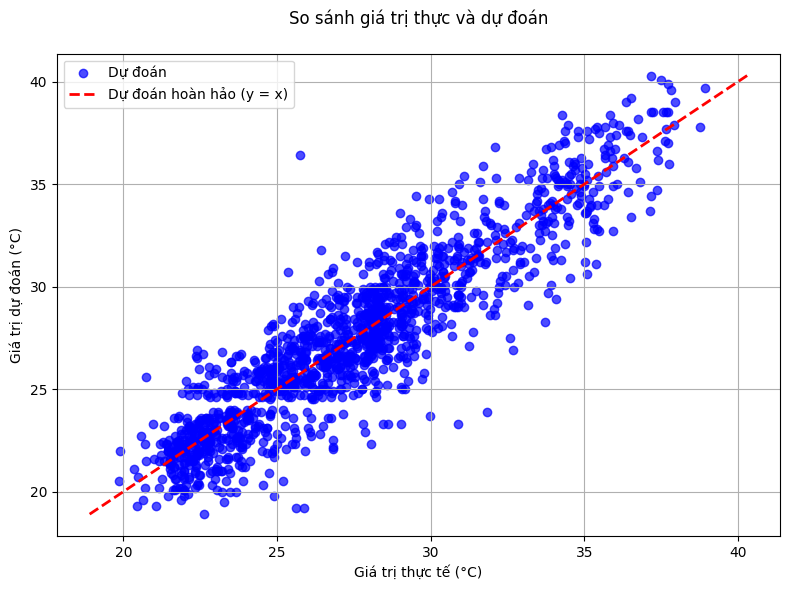

In [ ]:
mlp_model = XGBRegressor(**best_params, random_state=42, max_iter=200)
mlp_model.fit(X_train_scaled, y_train)

y_test_pred = mlp_model.predict(X_test_scaled)

print("\n=== Đánh giá trên Test Set ===")
print(f"Test MSE: {mean_squared_error(y_test, y_test_pred):.4f}")
print(f"Test R2 : {r2_score(y_test, y_test_pred):.4f}")

show_result(mlp_model)